# Projet de Machine Learning 

In [37]:
# Chargement des librairies nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)

# 1. Introduction


## Présentation du jeu de données 


Dans ce projet, nous nous intéressons à un jeu de données synthétique comprenant 15 000 dossiers de patients, intégrant des variables démographiques, physiologiques et comportementales (âge, IMC, pression artérielle, cholestérol, habitudes de vie, etc.). Bien que ces données soient artificielles, elles ont été construites de manière à reproduire des corrélations réalistes observées en pratique médicale.

L’objectif principal est de prédire le risque de maladie cardiovasculaire (Heart_Disease_Risk) à partir de l’ensemble des variables explicatives, en mobilisant différentes méthodes de machine learning. Dans un second temps, nous chercherons également à prédire le taux de cholestérol LDL, indicateur clé du risque cardiovasculaire.

Pour répondre à ces objectifs, nous commencerons par une analyse exploratoire approfondie des données afin de mieux comprendre leur structure et les relations entre variables. Nous comparerons ensuite plusieurs modèles de prédiction, en évaluant leurs performances et leur capacité d’interprétation. Enfin, nous discuterons la cohérence des résultats obtenus au regard de l’analyse descriptive initiale.

Les données sont extraites et mises en forme, elles sont décrites par les variables suivantes :
* **Patient_ID** : identifiant unique pour chaque patient ;  
* **Age** : âge du patient (en années) ;  
* **Gender** : genre du patient ; qualitative à deux modalités ;  
* **Height_cm** : taille du patient en centimètres ;  
* **Weight_kg** : poids du patient en kilogrammes ;  
* **BMI** : indice de masse corporelle (IMC), calculé à partir de la taille et du poids (kg/m²) ;  
* **Systolic_BP** : pression artérielle systolique (mmHg) ;  
* **Diastolic_BP** : pression artérielle diastolique (mmHg) ;  
* **Cholesterol_Total** : cholestérol sérique total (mg/dL) ;  
* **Cholesterol_LDL** : lipoprotéines de basse densité (« mauvais » cholestérol) (mg/dL) ;  
* **Cholesterol_HDL** : lipoprotéines de haute densité (« bon » cholestérol) (mg/dL) ;  
* **Fasting_Blood_Sugar** : taux de glycémie à jeun (mg/dL) ;  
* **Smoking_Status** : statut tabagique ; qualitative à deux modalités ;  
* **Alcohol_Consumption** : niveau de consommation d’alcool ; qualitative à trois modalités ;  
* **Physical_Activity_Level** : niveau d’activité physique ; qualitative à quatre modalités ;  
* **Family_History** : antécédents familiaux de maladie cardiaque ; qualitative à deux modalités ;  
* **Stress_Level** : niveau de stress auto-déclaré ; échelle de 1 à 10 ;  
* **Sleep_Hours** : nombre moyen d’heures de sommeil par nuit ;  
* **Heart_Disease_Risk** : risque d’accident cardiaque ; qualitative à deux modalités : 0 (risque faible) ou 1 (risque élevé).  

In [38]:
# Lecture des données
# path="http://www.math.univ-toulouse.fr/~besse/Wikistat/data/"
path <- "./"
data <- read.table(paste(path, "healthcare_synthetic_data.csv", sep = ""),
                    sep = ",", header = TRUE)
# Affiche les premières lignes du jeu de données 
head(data)
# Vérification du contenu
summary(data)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

## Prise en charge des données

In [39]:
# données "propres", sans trous, bien codées et de petites tailles ?

In [40]:
# Conversion des variables qualitatives en facteur 

data[, "Gender"] <- as.factor(data[, "Gender"])
data[, "Smoking_Status"] <- as.factor(data[, "Smoking_Status"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])


# 2. Analyse exploratoire des données

Étapes descriptives préliminaires uni- et multidimensionnelle visant à repérer les incohérences, les variables non significatives ou de distribution exotique, les individus non concernés ou atypiques... et à étudier les structures des données. Ce peut être aussi la longue étape de construction de variables, attributs ou features spécifiques des données.

## Analyse descriptive unidimensionnelles

### Variables qualitatives

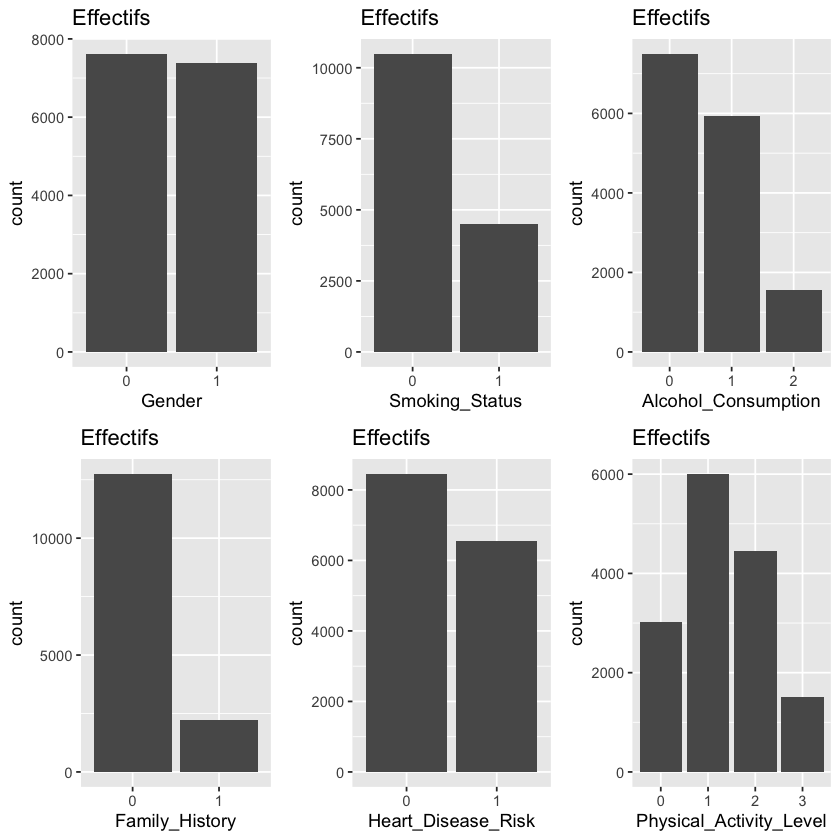

In [41]:

g1 <- ggplot(data) + geom_bar(aes(x = Gender )) + ggtitle("Effectifs")+xlab("Gender")
g2 <- ggplot(data) + geom_bar(aes(x = Smoking_Status)) + ggtitle("Effectifs")+xlab("Smoking_Status")
g3 <- ggplot(data) + geom_bar(aes(x = Alcohol_Consumption)) + ggtitle("Effectifs")+xlab("Alcohol_Consumption")
g4 <- ggplot(data) + geom_bar(aes(x = Family_History)) + ggtitle("Effectifs")+xlab("Family_History")
g5 <- ggplot(data) + geom_bar(aes(x = Heart_Disease_Risk)) + ggtitle("Effectifs")+xlab("Heart_Disease_Risk")
g6 <- ggplot(data) + geom_bar(aes(x = Physical_Activity_Level)) + ggtitle("Effectifs")+xlab("Physical_Activity_Level")

grid.arrange(g1, g2,  g3,g4, g5,g6 ,ncol= 3, nrow=2)


<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> La variable genre est équilibrée mais les variables Alcohol_Consumption et Smoking_Status sont fortement déséquilibrées. La variable Heart_Disease_Risk est ??? 
</div>


### Variables quantitatives continues

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


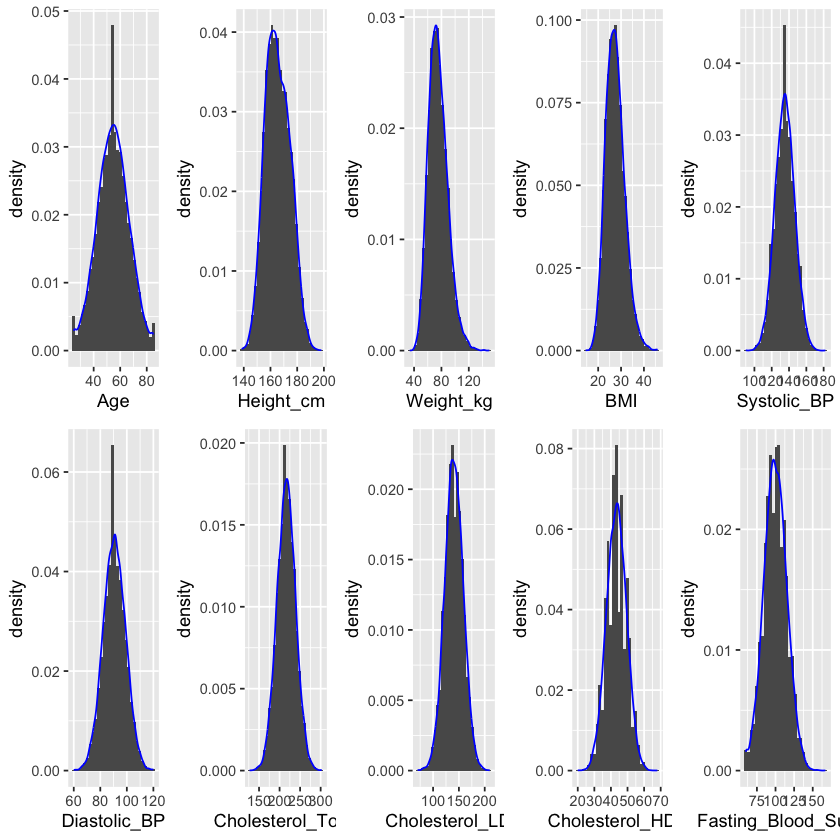

In [42]:
# Histogrammes des variables quantitatives continues
g1<-ggplot(data,aes(x=Age))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue") 
g2<-ggplot(data,aes(x=Height_cm))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g3<-ggplot(data,aes(x=Weight_kg))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g4<-ggplot(data,aes(x=BMI))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g5<-ggplot(data,aes(x=Systolic_BP))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g6<-ggplot(data,aes(x=Diastolic_BP))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g7<-ggplot(data,aes(x=Cholesterol_Total))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g8<-ggplot(data,aes(x=Cholesterol_LDL))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g9<-ggplot(data,aes(x=Cholesterol_HDL))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g10<-ggplot(data,aes(x=Fasting_Blood_Sugar))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
#g11<-ggplot(data,aes(x=Stress_Level))+
# geom_histogram(aes(y=after_stat(density)))+
#  geom_density(alpha=.2, col="blue")
#g12<-ggplot(data,aes(x=Sleep_Hours))+
#geom_histogram(aes(y=after_stat(density)))+
#geom_density(alpha=.2, col="blue")

grid.arrange(g1,g2,g3, g4, g5, g6, g7, g8, g9, g10, ncol=5, nrow=2)
rm(g1,g2,g3,g4,g5,g6,g7,g8, g9, g10)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> On observe des densités symétriques plutôt gaussiennes cela sera nécessaire pour certaines méthodes à venir de modélisation (linéaires), mais pas pour toutes (arbres).
Pas de transformation sur les données.
</div>

### Variables quantitatives discrètes 

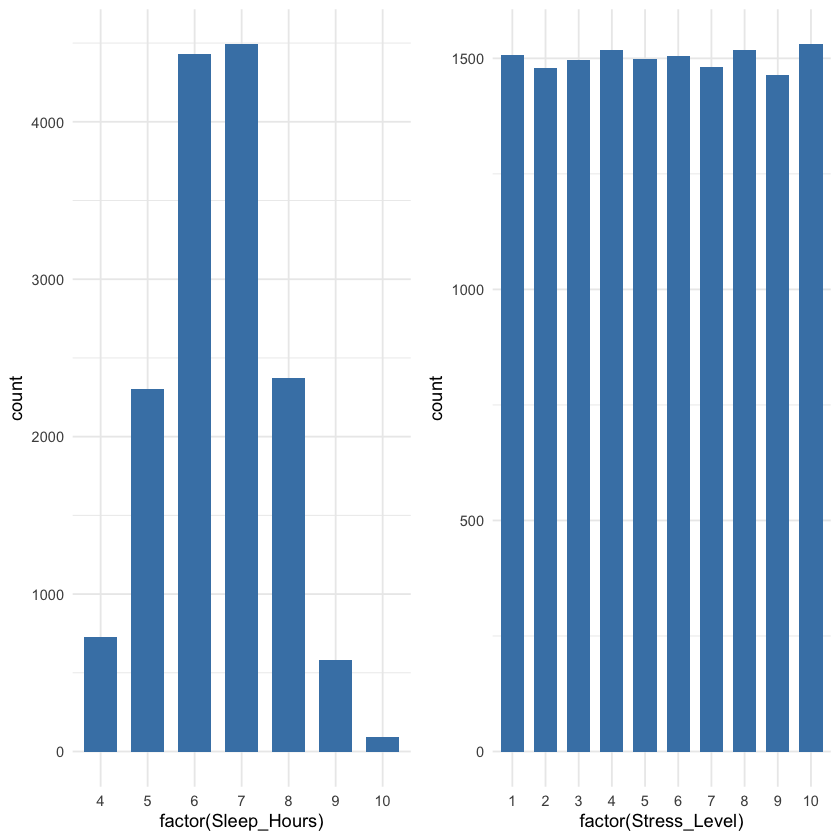

In [43]:
g1 <- ggplot(data, aes(x=factor(Sleep_Hours)))+
  geom_bar(stat="count", width=0.7, fill="steelblue")+
  theme_minimal()

g2 <- ggplot(data, aes(x=factor(Stress_Level)))+
  geom_bar(stat="count", width=0.7, fill="steelblue")+
  theme_minimal()

grid.arrange(g1, g2, ncol = 2)



## Analyse descriptive bidimensionnelles


### Entre variables quantitatives 

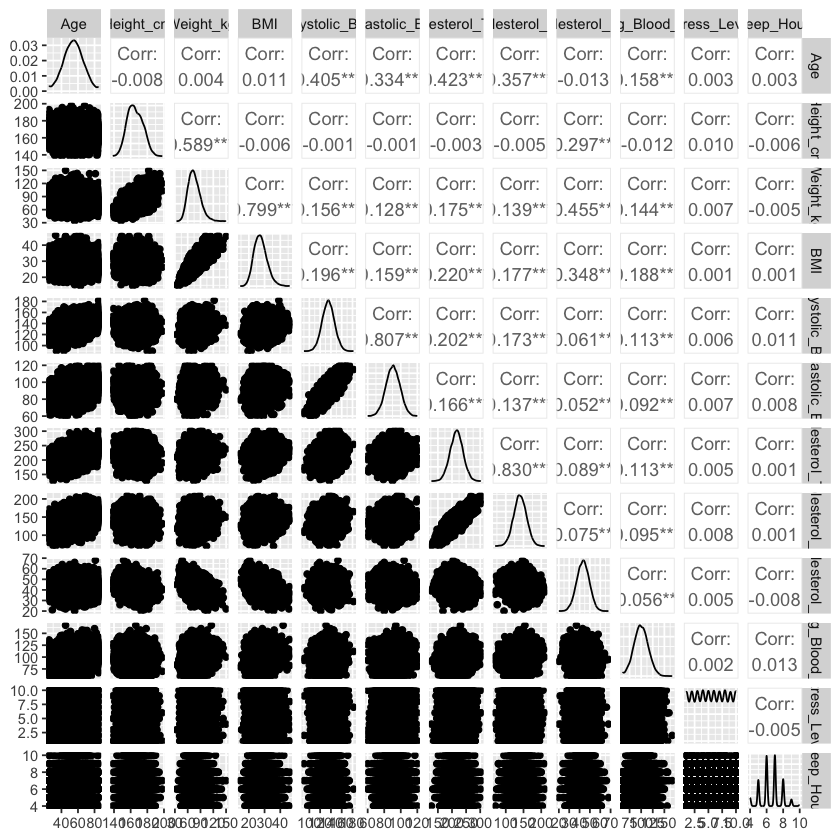

In [44]:
ggpairs(data[, c(2,4:12,17,18)])

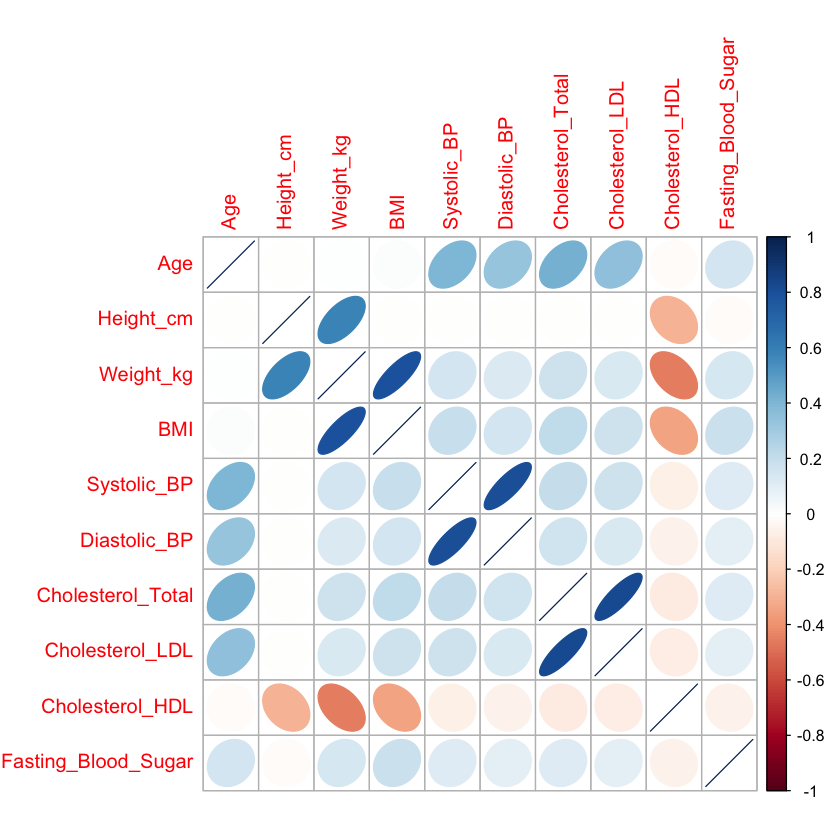

In [45]:
corrplot(cor(data[, c(2,4:12)]),method="ellipse")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> La plus forte corrélation observée est entre l'âge et la pression artérielle systolique (Systolic_BP), puis entre l'âge et la quantité de lipoprotéines de basse densité "mauvais cholestérol (Cholesterol_LDL).
    A garder en tête : le BMI se calcule avec Weight et Height (trouver un source, peut être une formule) et le chol Total c'est la somme des 2 autres
</div>

### Entre variables quantitatives et qualitatives

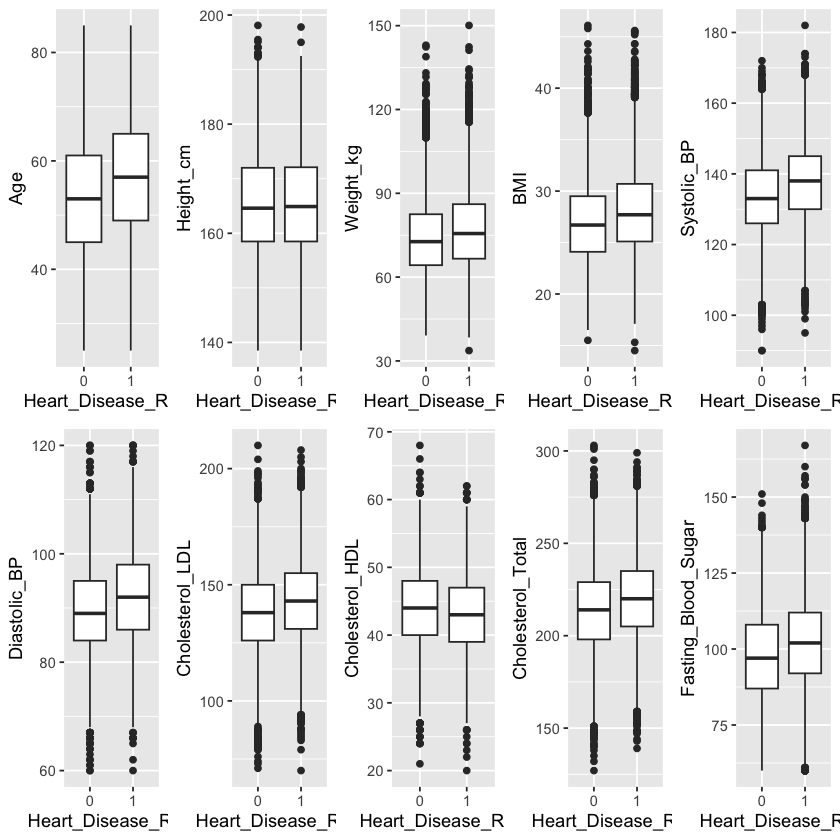

In [46]:

g1 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Age)) +
  geom_boxplot()

g2 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Height_cm)) +
  geom_boxplot()

g3 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Weight_kg)) +
 geom_boxplot()

g4 <- ggplot(data, aes(x = Heart_Disease_Risk, y = BMI)) +
  geom_boxplot()

g5 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Systolic_BP)) +
  geom_boxplot()

g6 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Diastolic_BP)) +
  geom_boxplot()

g7<- ggplot(data, aes(x = Heart_Disease_Risk, y = Cholesterol_LDL)) +
  geom_boxplot()

g8 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Cholesterol_HDL)) +
  geom_boxplot()

g9 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Cholesterol_Total)) +
  geom_boxplot()

g10 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Fasting_Blood_Sugar)) +
  geom_boxplot()

grid.arrange(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10,ncol = 5, nrow = 2)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> Ici on regarde le risque d’accident cardiaque en fonction des 10 variables quantitatives : 
    - Age : très légèrement plus risqué quand on est plus agé 
    - Weight : pareil 
    - Dia et Sys BP : risqué pour les valeurs élevées 
    - Cho LDL et HDL et Total : pareil 
    - Fasting Blood Sugar
    
</div>

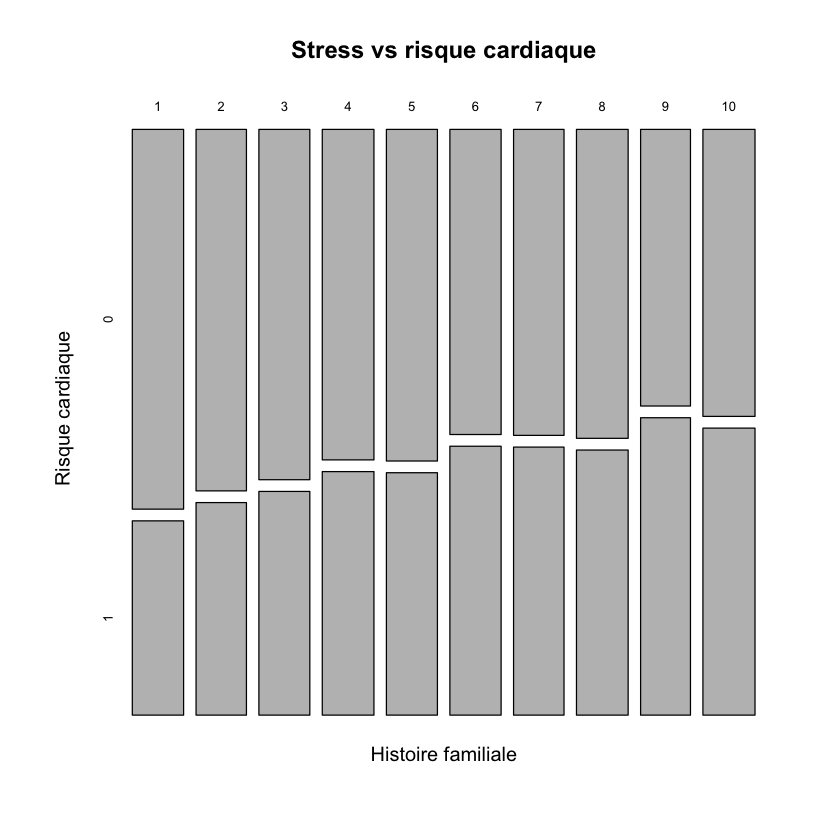

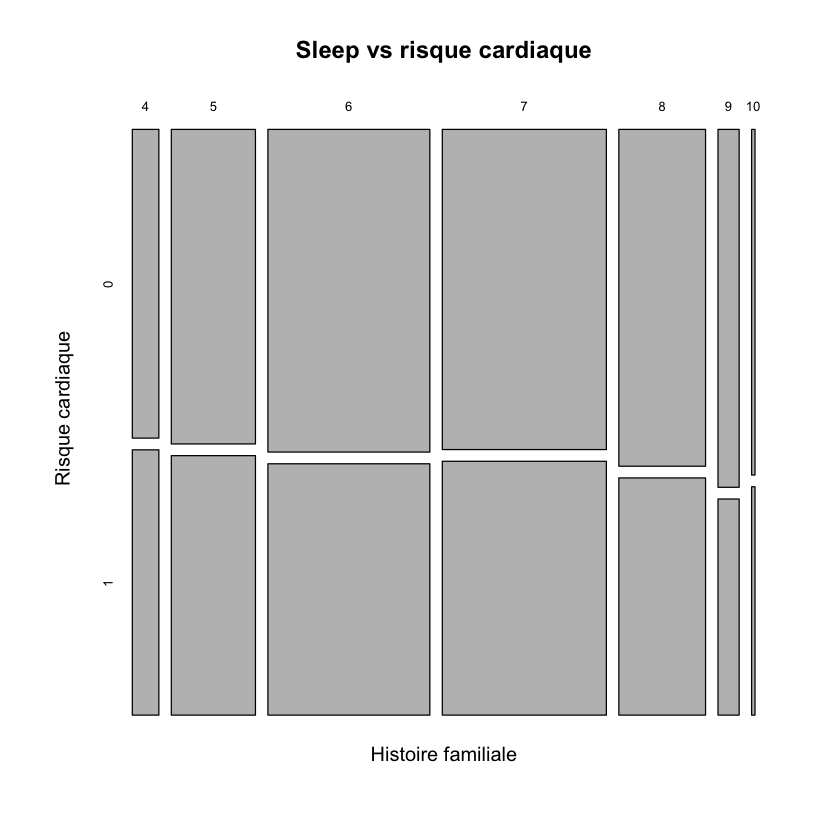

In [36]:
mosaicplot(
  table(data$Stress_Level, data$Heart_Disease_Risk),
  xlab = "Histoire familiale",
  ylab = "Risque cardiaque",
  main = "Stress vs risque cardiaque"
)
mosaicplot(
  table(data$Sleep_Hour, data$Heart_Disease_Risk),
  xlab = "Histoire familiale",
  ylab = "Risque cardiaque",
  main = "Sleep vs risque cardiaque"
)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> Ici on regarde le risque d’accident cardiaque en fonction de Sleep et Stress :
    -  Legère augmentation de proportion de patient à risque élevé quand le niveau de stress augmente 
    - Parmis les personnes déclarant 8/9 heures de sommeil on observe une proportion de risque légèrement moins élevé que pour 4à7 heures. On remarque une très légère augmentation du de proportion de risque à 10h de sommeil.
    
</div>

In [ ]:
### Entre variables qualitatives

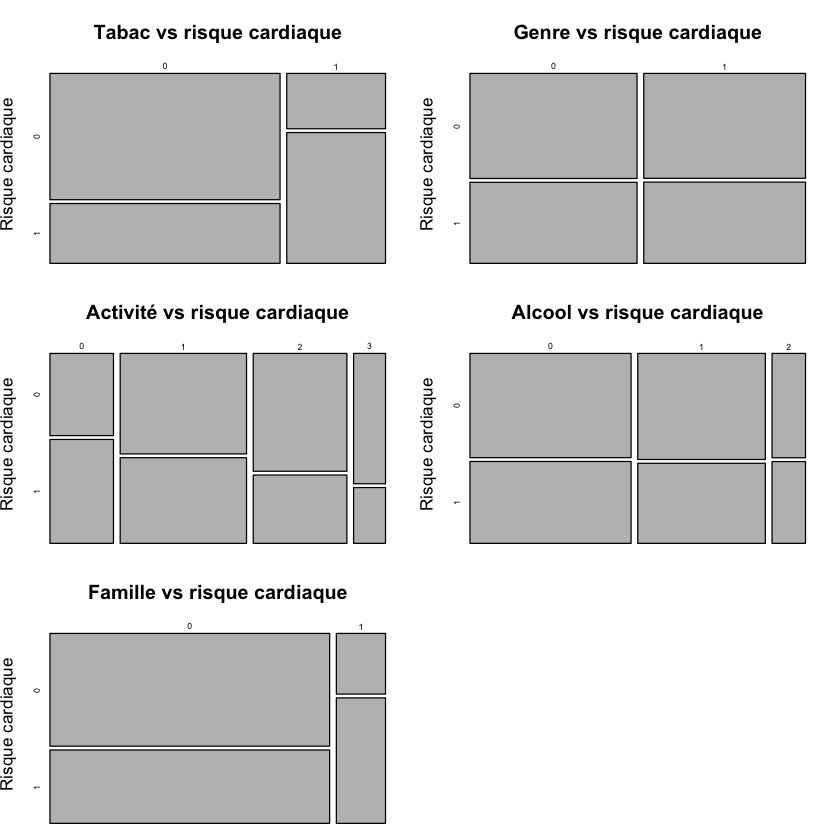

In [48]:
# Mettre 2 lignes et 3 colonnes pour afficher plusieurs plots sur une seule fenêtre
par(mfrow = c(3, 2), mar = c(1, 2, 4, 1), cex.axis = 1.2, cex.lab = 1.3, cex.main = 1.5) # 'mar' ajuste les marges pour que ce soit plus compact

# Mosaic plots
mosaicplot(
  table(data$Smoking_Status, data$Heart_Disease_Risk),
  xlab = "Statut tabagisme",
  ylab = "Risque cardiaque",
  main = "Tabac vs risque cardiaque"
)

mosaicplot(
  table(data$Gender, data$Heart_Disease_Risk),
  xlab = "Genre",
  ylab = "Risque cardiaque",
  main = "Genre vs risque cardiaque"
)

mosaicplot(
  table(data$Physical_Activity_Level, data$Heart_Disease_Risk),
  xlab = "Activité physique",
  ylab = "Risque cardiaque",
  main = "Activité vs risque cardiaque"
)

mosaicplot(
  table(data$Alcohol_Consumption, data$Heart_Disease_Risk),
  xlab = "Consommation alcool",
  ylab = "Risque cardiaque",
  main = "Alcool vs risque cardiaque"
)

mosaicplot(
  table(data$Family_History, data$Heart_Disease_Risk),
  xlab = "Histoire familiale",
  ylab = "Risque cardiaque",
  main = "Famille vs risque cardiaque"
)


<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> 
    - Proportion de risque cardiaque plus élevée chez les fumeurs et chez les patients avec un antécédent dans leur famille 
    - Pas de distinction de genre,ou consommation d'Alcohol 
    - Proportion de personne avec rique élevé + élevée chez les personnes avec une faible activité physique(0), la proportion diminue quand l'activité physique est plus importante
    
</div>

## ACP

### Sélection du nombre de dimensions

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


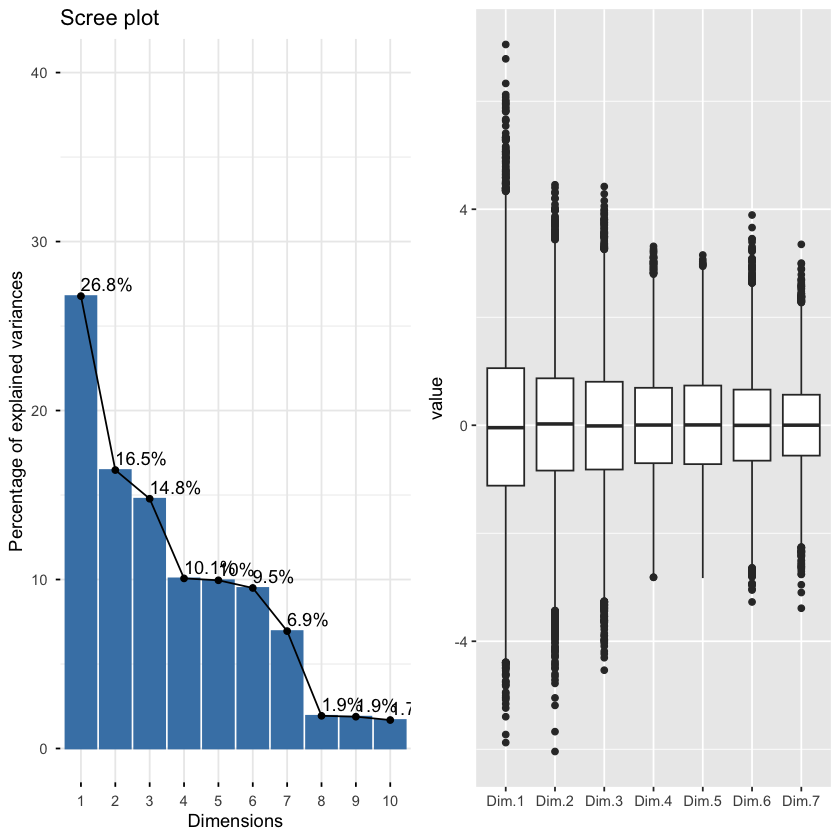

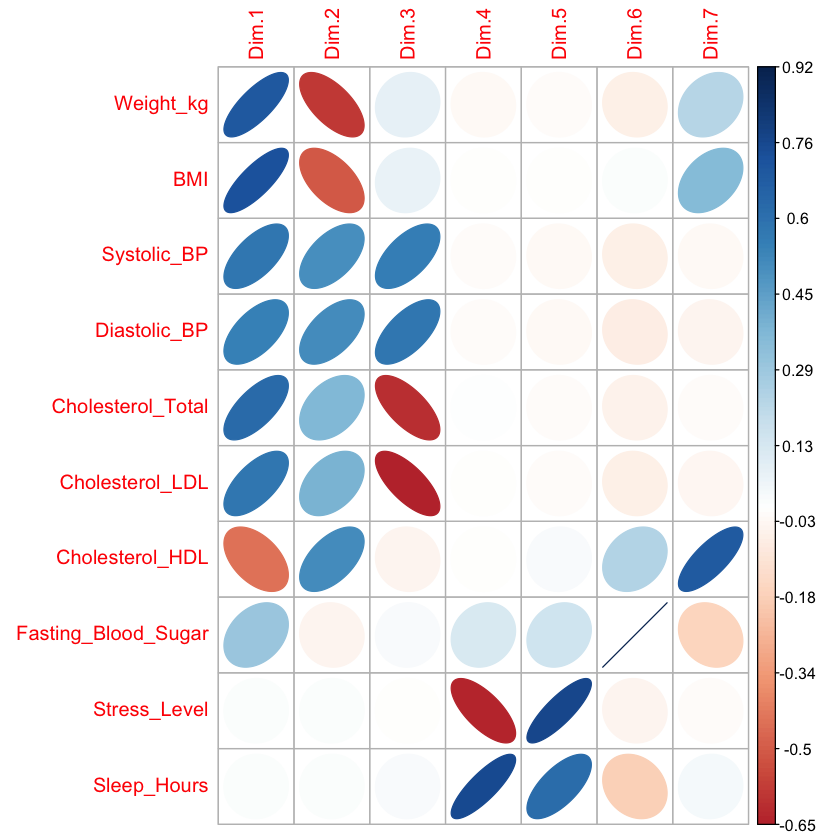

In [14]:
dataquant = data[, c(2,c(4:12,17,18))]
acp <- PCA(dataquant, scale.unit = TRUE,
           graph = FALSE, quali.sup = 1, quanti.sup = 2, ncp = 7)
# Décroissance des valeurs propres
g1<-fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))
library(reshape2)
g2<-ggplot(melt(acp$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)

corrplot(acp$var$cor, is.corr=FALSE,method="ellipse")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b>  Critère de sélection : rupture nette dans la décroissance des valeurs propres
Si on garde 4 dim : 68.21 % de la variations est représentée + corrplot dim 4 représente stress_level et sleep_hours pareil que dim 5 mais sans sleep_hours
</div>

### Interprétation des dims

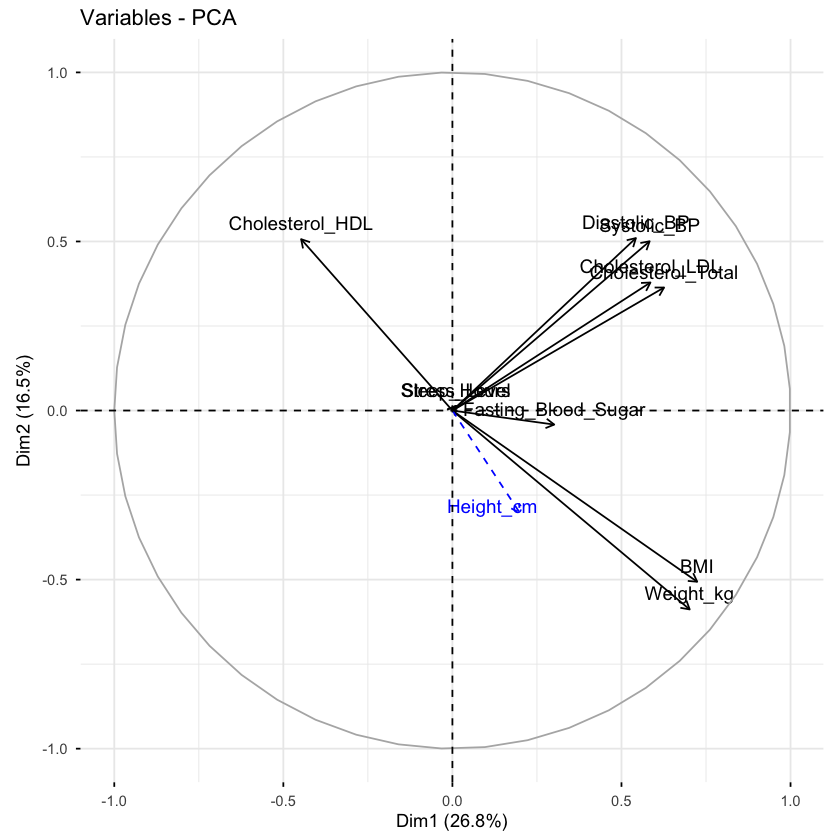

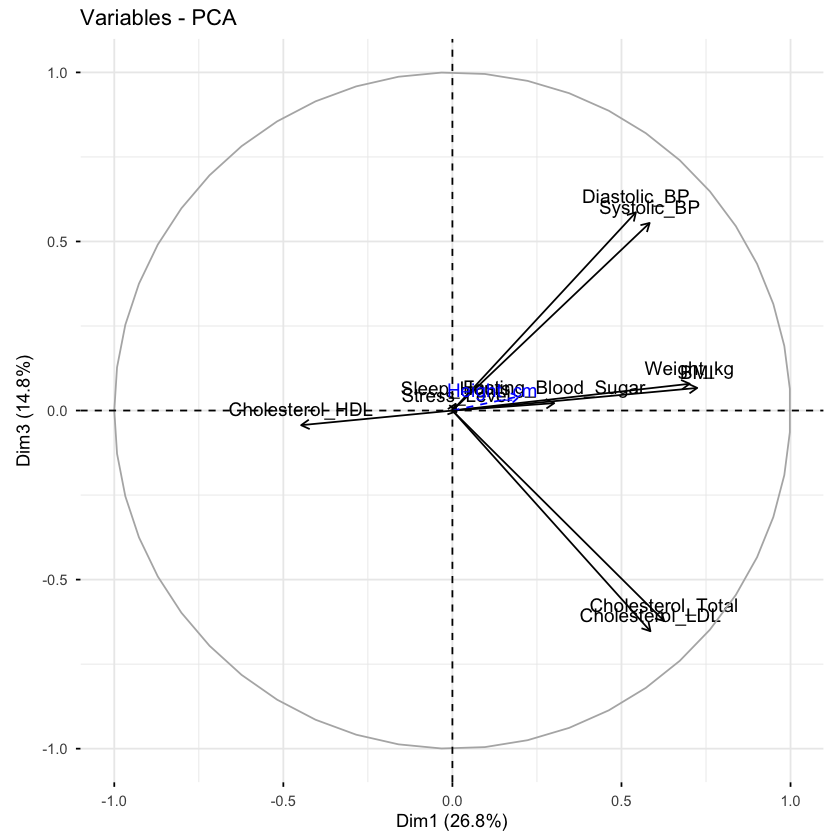

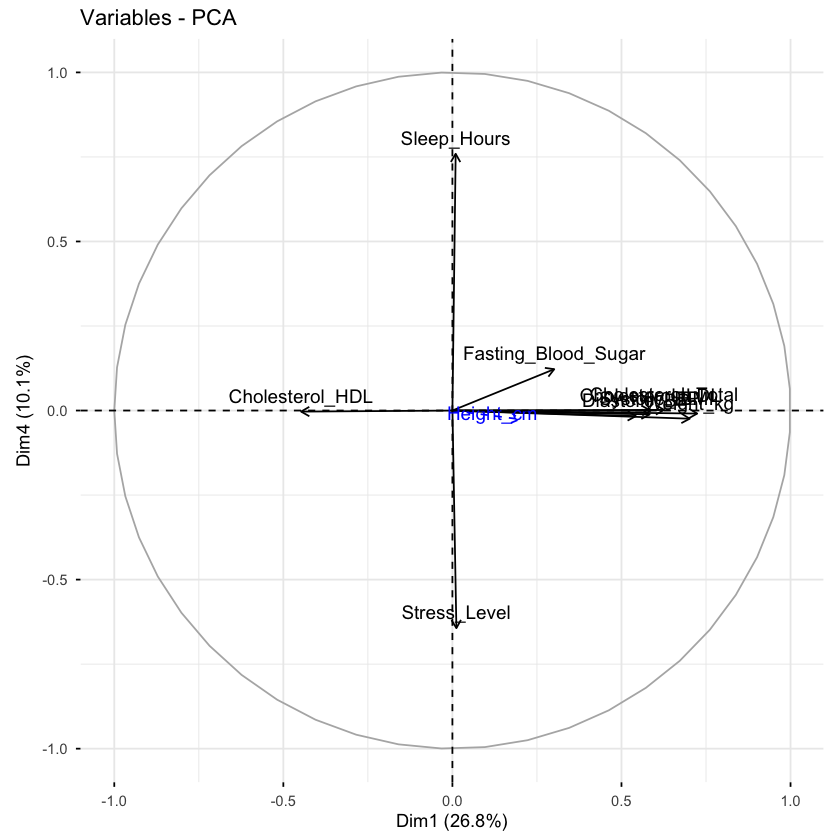

In [16]:
#ACP DIm 1
fviz_pca_var(acp)
#fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))
fviz_pca_var(acp,axes=c(1,3))
#fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))
fviz_pca_var(acp,axes=c(1,4))

#ACP DIm 2
#fviz_pca_var(acp,axes=c(2,3))
#fviz_pca_var(acp,axes=c(2,4))

#ACP DIm 2
#fviz_pca_var(acp,axes=c(3,4))


<div style="border-left:5px solid orange; padding:15px; background-color:#fff8e1; border-radius:5px; font-family:Arial, sans-serif; line-height:1.6;">
  <strong>Interprétation  (c'est pas rédigé) :</strong><br><br>1vs2: Cholesterol_HDL (- dim 1, + dim 2), BIM et Weigth (+ dim 1, -dim2), le reste (+dim1, +dim2), Heigth et Fasting Blood sugar pas tant important 
1vs3: Cholesterol_HDL(- dim 1), Séparation des variables : (Diastolic, Systolic), (BMI, Weigth), (Cholesterol Total, Cholesterol LDL)
1vs4 : Cholesterol_HDL(- dim 1), + dim2 tout les restes des var quantitatives (même importance pour toutes,+dim4 : Sleep et - dim 4 Stress_Lecel

2vs3 : + dim 2 : Cholesterol H , -dim2 = Weight, BMI,Height + dim 2/3  : BP, -dim2/3: Cholesterol
2vs4 : +dim4 : Sleep et - dim 4 Stress_Lecel, -dim2 = weigth, heigth, BMI, +dim 2 : tout le reste

3vs4 : idem dim 4, dim3 +: PB , dim3: CholLDL et Total
tre elles.
</div>

### Graphs des individus ( A FAIRE : sans habillage raw)

Habillage selon HeartRisk

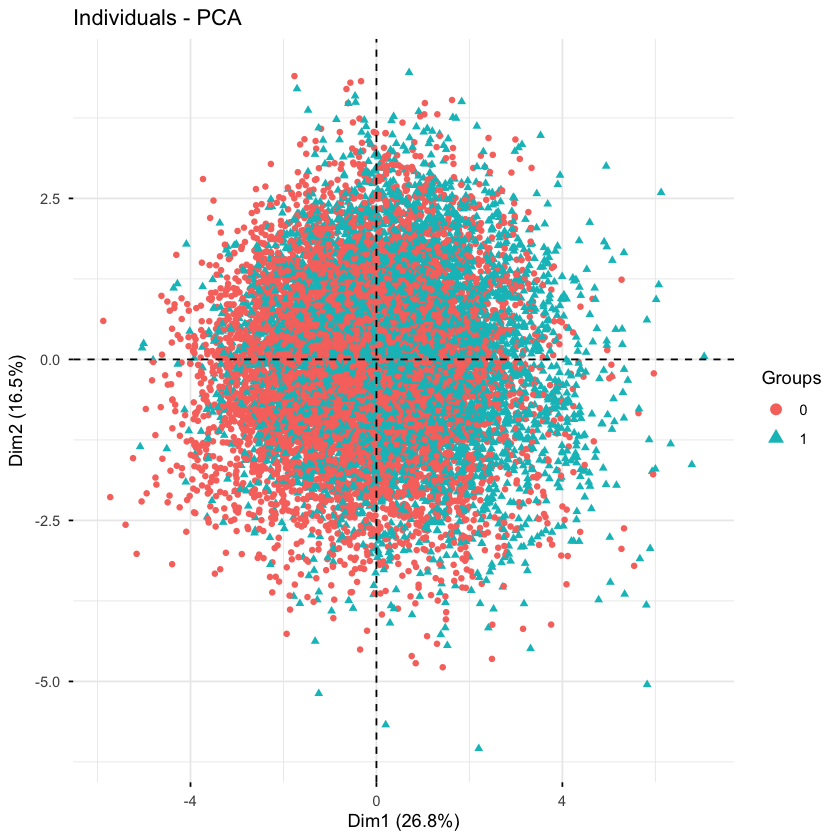

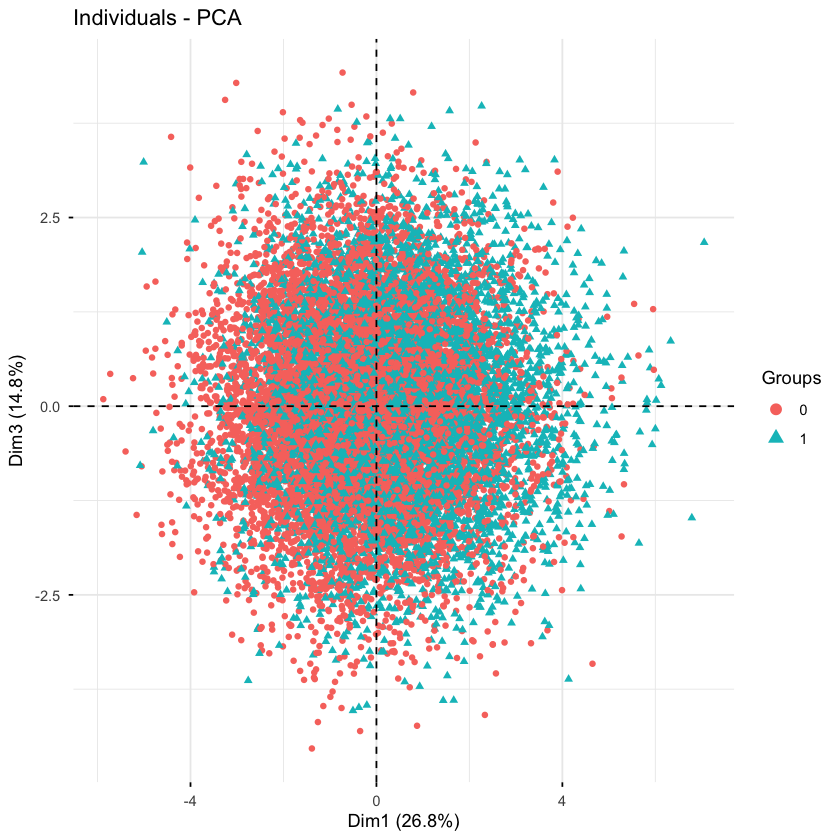

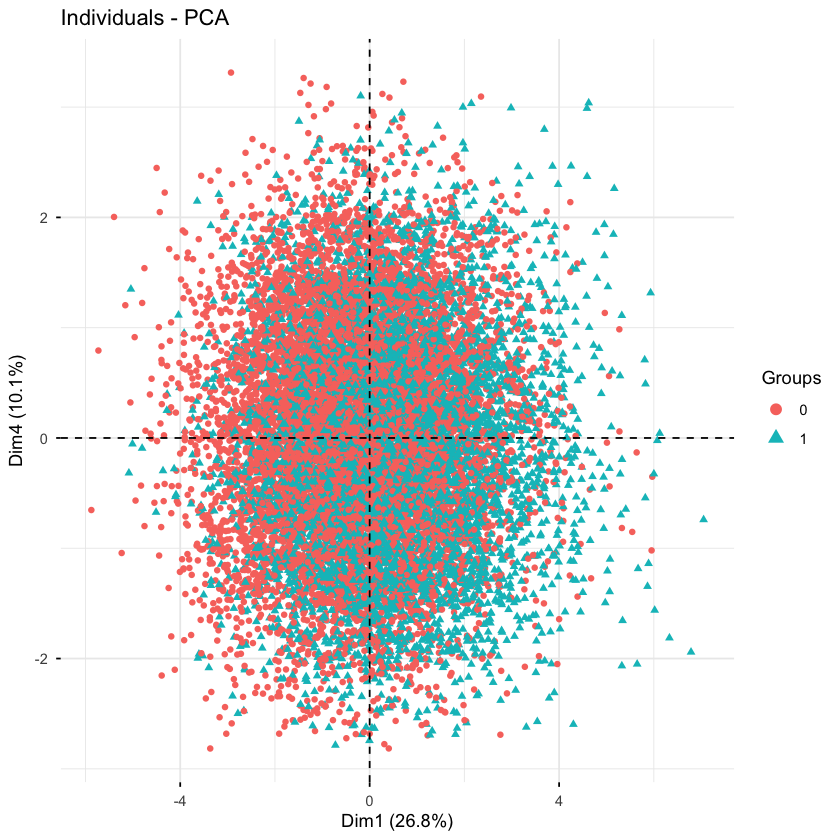

In [20]:
fviz_pca_ind(acp, label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)
fviz_pca_ind(acp,axes=c(1,3), label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)
fviz_pca_ind(acp,axes=c(1,4), label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)

#Graph sur les autres dimensions mais c'est terrible aussi
#fviz_pca_ind(acp,axes=c(2,3), label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)
#fviz_pca_ind(acp,axes=c(2,4), label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)
#fviz_pca_ind(acp,axes=c(3,4), label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)

<div style="border-left:5px solid orange; padding:15px; background-color:#fff8e1; border-radius:5px; font-family:Arial, sans-serif; line-height:1.6;">
  <strong>Interprétation : (c'est pas rédigé) </strong><br><br>

Pas discrimination linéaire possible sur les 4 premiers hyperplans. 
</div>

### Clustering

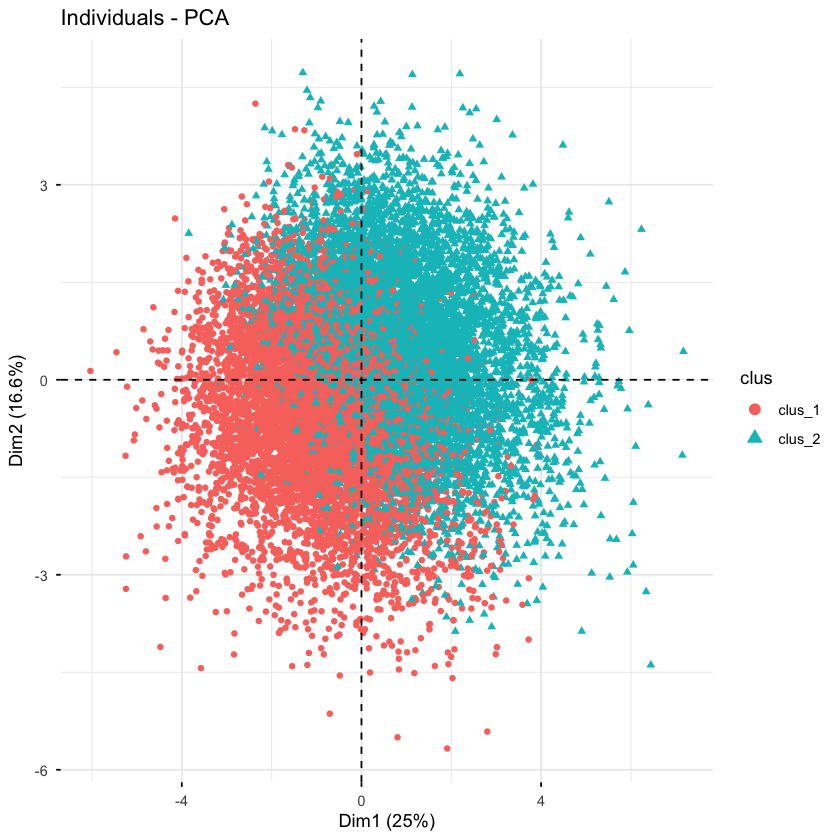

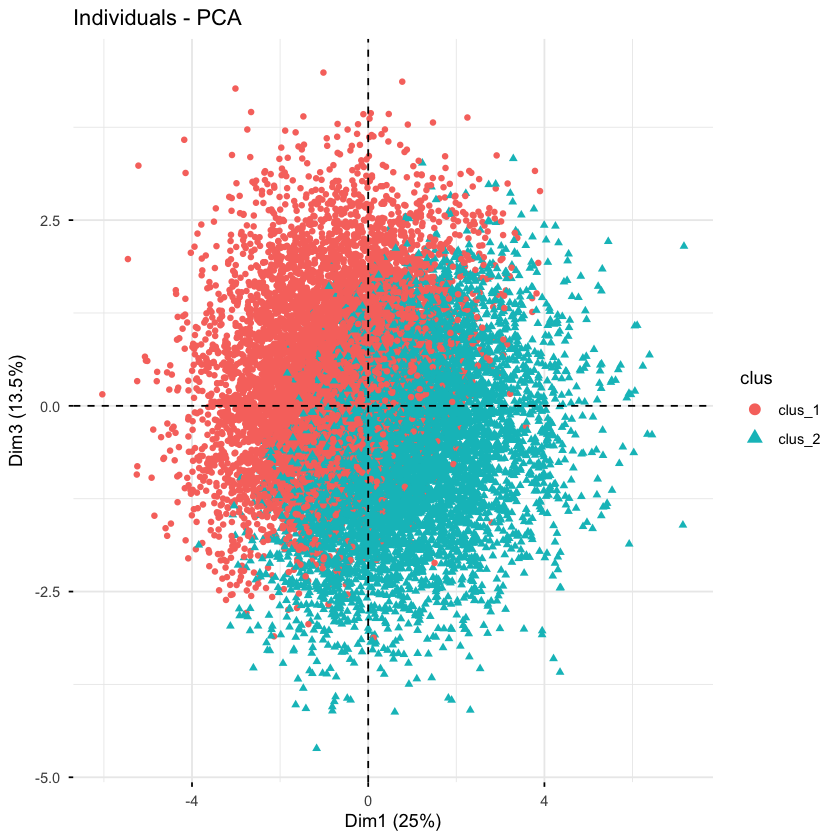

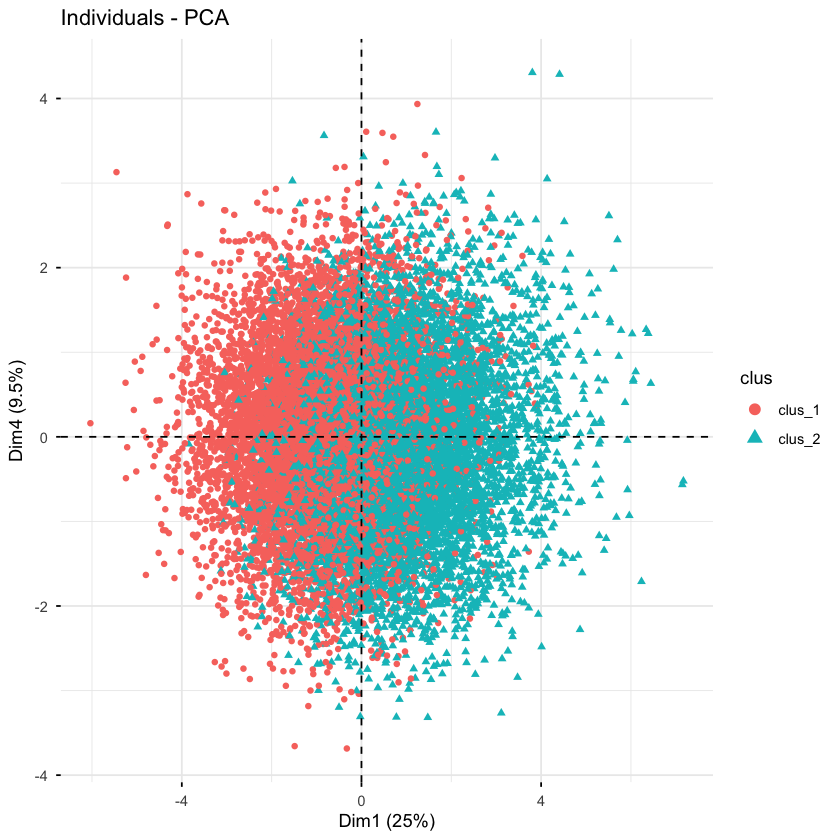

In [21]:
km.data <- kmeans(dataquant ,centers = 2)

# Représentation dans les coordonnées de l'acp
acp2 <- PCA(cbind(clus = as.factor(km.data$cluster),
          dataquant), scale.unit = TRUE,
          graph = FALSE, quali.sup = 1:2, ncp = 7)
fviz_pca_ind(acp2, label="none", habillage="clus")
fviz_pca_ind(acp2, label="none", habillage="clus", axes= c(1,3))
fviz_pca_ind(acp2, label="none", habillage="clus", axes= c(1,4))

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b>  
    Clustering de 2 plus concluant que l'habillage simple.
    Séparation pas super nette, pas mal d'overlapping.
    Dim 1v2 : DP et Cho LDL et Total pour le cluster 2
    Dim 1v3 : Cho LDL et Total pour le cluster 2
    Dim 1v4 : Cho HDL pour le clus 1
    Observation : Sleep et Stress ne semblent pas contribué au cluster pas de distinction sur la dim 4.
</div>

# 3. Modélisation

###  Division du jeu de données en un échantillon d’apprentissage et un échantillon test

Pour évaluer correctement un modèle, on divise le jeu de données en échantillon d’apprentissage (80%) et échantillon test (20%). L’échantillon d’apprentissage sert à entraîner le modèle, tandis que l’échantillon test permet de mesurer ses performances sur des données jamais vues. Cette étape est nécessaire pour éviter le surapprentissage et obtenir une estimation réaliste de la capacité du modèle à généraliser à de nouvelles données.

In [24]:
set.seed(111) # initialisation du générateur
# Extraction des échantillons
test.ratio <- .2   # part de l'échantillon test
npop <- nrow(data) # nombre de lignes dans les données
nvar <- ncol(data) # nombre de colonnes
# taille de l'échantillon test
ntest <- ceiling(npop * test.ratio) 
# indices de l'échantillon test
testi <- sample(1:npop, ntest)
# indices de l'échantillon d'apprentissage
appri <- setdiff(1:npop, testi) 

Construction des échantillons pour la régression: prévision du risque d’accident cardiaque "Heart_Disease_Risk".

In [35]:
# construction de l'échantillon d'apprentissage
datappr0 <- data[appri, -19] # on retire la colonne "Heart_Disease_Risk"

# construction de l'échantillon test
datestr0 <- data[testi, -19] 

# vérification
str(datappr0)
str(datestr0)

# on identifie les colonnes numériques
num_cols <- sapply(datappr0, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr <- datappr0
datappr[, num_cols] <- scale(datappr0[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr <- datestr0
datestr[, num_cols] <- scale(
  datestr0[, num_cols],
  center = sapply(datappr0[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
summary(datappr)
summary(datestr)

'data.frame':	12000 obs. of  18 variables:
 $ Patient_ID             : chr  "PID-00001" "PID-00002" "PID-00003" "PID-00004" ...
 $ Age                    : int  60 53 62 73 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  147 162 175 173 160 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 60.3 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  140 128 141 136 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  89 81 100 96 92 98 90 91 91 100 ...
 $ Cholesterol_Total      : int  217 203 173 193 225 260 237 227 206 188 ...
 $ Cholesterol_LDL        : int  151 119 124 117 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  52 38 45 45 48 46 44 37 38 43 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 

  Patient_ID             Age           Gender     Height_cm       
 Length:12000       Min.   :-2.46911   0:6083   Min.   :-2.91995  
 Class :character   1st Qu.:-0.71488   1:5917   1st Qu.:-0.74279  
 Mode  :character   Median : 0.03694            Median :-0.06788  
                    Mean   : 0.00000            Mean   : 0.00000  
                    3rd Qu.: 0.70522            3rd Qu.: 0.73767  
                    Max.   : 2.54298            Max.   : 3.53532  
   Weight_kg             BMI           Systolic_BP        Diastolic_BP     
 Min.   :-2.95670   Min.   :-3.1570   Min.   :-3.98919   Min.   :-3.60504  
 1st Qu.:-0.71629   1st Qu.:-0.7112   1st Qu.:-0.71768   1st Qu.:-0.65311  
 Median :-0.09554   Median :-0.0753   Median :-0.01033   Median : 0.05535  
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.61796   3rd Qu.: 0.6340   3rd Qu.: 0.69702   3rd Qu.: 0.64573  
 Max.   : 5.34851   Max.   : 4.4984   Max.   : 4.14536   Max.   : 3.47959  

  Patient_ID             Age            Gender     Height_cm        
 Length:3000        Min.   :-2.469112   0:1539   Min.   :-2.919954  
 Class :character   1st Qu.:-0.631343   1:1461   1st Qu.:-0.742795  
 Mode  :character   Median :-0.046599            Median :-0.067876  
                    Mean   :-0.008228            Mean   : 0.007207  
                    3rd Qu.: 0.621681            3rd Qu.: 0.715902  
                    Max.   : 2.542985            Max.   : 3.567980  
   Weight_kg             BMI            Systolic_BP         Diastolic_BP      
 Min.   :-2.52147   Min.   :-2.59448   Min.   :-3.547092   Min.   :-3.132733  
 1st Qu.:-0.70202   1st Qu.:-0.71121   1st Qu.:-0.629264   1st Qu.:-0.653114  
 Median :-0.05987   Median :-0.05084   Median :-0.010330   Median :-0.003690  
 Mean   : 0.04050   Mean   : 0.04674   Mean   : 0.000368   Mean   : 0.005914  
 3rd Qu.: 0.66791   3rd Qu.: 0.65845   3rd Qu.: 0.697022   3rd Qu.: 0.645734  
 Max.   : 4.54939   Max.   : 4.57174   Max.

In [41]:
# code pour trouver les variables numeric mais inutile 
# str(datappr0)  # regarde le type de chaque colonne
# sapply(datappr0, class)  # renvoie le type

In [59]:
#Enfin, avant de passer aux différents algorithmes, définissons une fonction traçant le graphe des résidus avec des couleurs et des échelles fixes sur les axes.
#c'était dans le TP à voir si c'est utile

gplot.res <- function(x, y, titre = "titre"){
    ggplot(data.frame(x=x, y=y),aes(x,y))+
    geom_point(col = "blue")+xlim(0, 250)+ylim(-155, 155)+
    ylab("Résidus")+ xlab("Valeurs prédites")+
    ggtitle(titre)+
    geom_hline(yintercept = 0,col="green")
}

consigne : Comparez les performances d’un modèle linéaire (éventuellement généralisé) avec/sans sélection de vari
ables, avec/sans pénalisation, d’un SVR/SVM, d’un arbre optimal, d’une forêt aléatoire, du boosting,
et de réseaux de neurones. Justifiez vos choix (par exemple le noyau pour le SVR/SVM), identifiez les
hyperparamètres de chaque modèle et ajustez-les soigneusement (par validation croisée). Interprétez les
résultats et quantifiez l’amélioration éventuelle apportée par les modèles non linéaires.

## 3.1 Prévision par modèle linéaire Gaussien 

modèle linéaire (éventuellement généralisé) avec/sans sélection de vari
ables, avec/sans pénalisatio. 

### 3.1.1 Sans sélection de variables

### 3.1.2. Sélection de variable par régularisation L1 (LASSO)

### 3.1.3 Modèle linéaire généralisé (quadratique)

### 3.1.4 Sélection de variables par critère AIC

### 3.1.5 Sélection de variable par régularisation L1 (LASSO)

### 3.1.6 Prévision de l'échantillon test

## Prévision par SVR/SVM (séparation à vaste marge)

## Prévision par arbre optimal

## Prévision par forêt aléatoire

## Prévision par boosting

## Prévision par réseaux de neurones